In [1]:
import pandas as pd
import os
import glob
from read_inf_list import get_inference_file_info
from dataloader_inf import open_dataset_inf, open_datasets_inf
from validation_statistics import create_stat_csv_plot_multiple_inf
from distribution_comparison import create_distribution_plots

In [2]:
import pandas as pd
import os
import glob
import ast  # To safely evaluate string representations of lists

def get_inference_file_info(infile):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(infile, comment='#')
    # Initialize lists to collect data
    inference_files_paths = []
    inference_run_id      = []
    inferece_epoch        = []
    plot_titles           = []
    # Variables to check for consistency
    inf_date_set   = set()
    inf_length_set = set()
    variables_set  = set()
    for i in df.index:
        inf_path  = df['inference_file'][i]
        # Safely parse the string representation of a path if needed
        if isinstance(inf_path, str):
            try:
                # Handle cases where the path might look like a string with extra quotes
                inf_path = ast.literal_eval(inf_path)
            except (ValueError, SyntaxError):
                pass  # If parsing fails, assume it's already a clean string
        inf_file  = inf_path.split('/')[-1]
        inf_vars  = df['variables'][i]
        plt_title = df['plot_title'][i]
        # Handle default values for plot_title
        if plt_title == '' or plt_title == '*':
            plt_title = inf_file[-21:-4]
        # Handle default values or parse provided variables
        #print(inf_vars)
        if inf_vars == '' or inf_vars == '*':
            inf_vars = ['salinity', 
                        'temperature', 
                        'u_eastward', 
                        'v_northward']
        else:
            # Safely parse the string representation of a list into an actual list
            if isinstance(inf_vars, str):
                #print(f'isinstance(inf_vars, str) == {isinstance(inf_vars, str)}')
                #print(inf_vars)
                try:
                    #inf_vars = ast.literal_eval(inf_vars)  # Convert string to list
                    # Ensure the string looks like a list before parsing
                    if not (inf_vars.startswith('[') and inf_vars.endswith(']')):
                        inf_vars = [inf_vars]  # Convert single variable to a list
                    else:
                        # Fix missing commas between items
                        inf_vars = inf_vars.replace("''", "', '")
                    # Convert string to a list
                    inf_vars = ast.literal_eval(inf_vars)
                except (ValueError, SyntaxError):
                    raise ValueError(f"Invalid format for variables: {inf_vars}")
            # Ensure variables are sorted for consistency
            inf_vars = sorted([var.strip() for var in inf_vars])
        # Extract information from the file name
        inf_date   = inf_file[0:10]
        inf_length = inf_file[11:14]
        inf_run_id = inf_file[15:20]
        inf_epoch  = inf_file[21:33]
        # Collect the extracted information
        inference_files_paths.append(inf_path)
        inference_run_id.append(inf_run_id)
        inferece_epoch.append(inf_epoch)
        plot_titles.append(plt_title)
        # Add to consistency check sets
        inf_date_set.add(inf_date)
        inf_length_set.add(inf_length)
        variables_set.add(tuple(inf_vars))  # Add variables as a tuple for immutability
    # Check if all inference files have the same date, length, and variables
    if len(inf_date_set) > 1:
        raise ValueError(f"Inconsistent inference dates found: {inf_date_set}")
    if len(inf_length_set) > 1:
        raise ValueError(f"Inconsistent inference lengths found: {inf_length_set}")
    if len(variables_set) > 1:
        raise ValueError(f"Inconsistent variables found: {variables_set}")
    # Prepare the plot dictionary
    plot_dict = {
        'inf_date'            : inf_date_set.pop(),         # Get the single consistent date
        'variables'           : list(variables_set.pop()),  # Convert the single consistent tuple back to a list
        'inf_length'          : inf_length_set.pop(),       # Get the single consistent length
        'number_of_inf_files' : len(inference_files_paths)
    }
    # Return the requested data
    return inference_files_paths, plot_titles, inference_run_id, inferece_epoch, plot_dict

def create_directory(path: str):
        """
        Create a directory if it does not exist, and handle the case where it already exists.
        """
        try:
            # Try to create the directory
            os.makedirs(path, exist_ok=False)
            print(f"Directory '{path}' created successfully.")
        except FileExistsError:
            # Handle the case where the directory already exists
            print(f"Directory '{path}' already exists. Skipping creation.")



In [3]:
inference_files_paths, plot_titles, inference_run_id, inferece_epoch, plot_dict = get_inference_file_info(infile='inference_list.csv')

In [4]:
plot_titles

["'lr3.5e-4'", "'lr3.5e-4-roll-out'", "'no-salt'", "'2m'", "'2m-roll-out'"]

In [5]:
plot_dict

{'inf_date': '2024-04-02',
 'variables': ['temperature', 'u_eastward', 'v_northward'],
 'inf_length': '48h',
 'number_of_inf_files': 5}

In [6]:
import xarray as xr
inf_2m = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/experiments/2m-depth/results/2024-04-02_48h_e655e_e013_s054000.nc')
inf_2m

<xarray.Dataset>
Dimensions:        (X: 1148, Y: 2747, time: 16)
Coordinates:
  * X              (X) float64 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * Y              (Y) float64 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * time           (time) datetime64[ns] 2024-04-02T03:00:00 ... 2024-04-04
Data variables:
    latitude       (X, Y) float32 ...
    longitude      (X, Y) float32 ...
    salinity_2     (time, X, Y) float32 ...
    temperature_2  (time, X, Y) float32 ...
    u_eastward_2   (time, X, Y) float32 ...
    v_northward_2  (time, X, Y) float32 ...

In [3]:
infile = 'inference_list.csv'
#df = pd.read_csv(infile, comment='#')
inference_files_paths, plot_titles, inference_run_id, inferece_epoch, plot_dict = get_inference_file_info(infile)
norkyst3, havbris_combined = open_datasets_inf(inference_files_paths,
                    truth_norkyst3_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/',
                    truth_file_name_template = "{year}/norkyst800-{year}{month:02d}{day:02d}.nc",
                    variables=plot_dict['variables'],
                    s_rho = -1,
                    crop_border = True,
                    debug=True)

Try to read file : /lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_48h_2ae52_e030_s120436.nc

File exists!

File exists and is read!

Variables in the dataset:
['lat', 'lon', 'h', 'salinity', 'sea_mask', 'temperature', 'u_eastward', 'v_northward', 'zeta', 'Pair', 'Qair', 'Tair', 'Uwind', 'Vwind', 'cos_julian_day', 'cos_latitude', 'cos_local_time', 'cos_longitude', 'f', 'insolation', 'rain', 'river_binary_mask', 'sin_julian_day', 'sin_latitude', 'sin_local_time', 'sin_longitude']

Inferred time-steps:
['2024-04-02T00:00:00.000000000' '2024-04-02T03:00:00.000000000'
 '2024-04-02T06:00:00.000000000' '2024-04-02T09:00:00.000000000'
 '2024-04-02T12:00:00.000000000' '2024-04-02T15:00:00.000000000'
 '2024-04-02T18:00:00.000000000' '2024-04-02T21:00:00.000000000'
 '2024-04-03T00:00:00.000000000' '2024-04-03T03:00:00.000000000'
 '2024-04-03T06:00:00.000000000' '2024-04-03T09:00:00.000000000'
 '2024-04-03T12:00:00.000000000' '2024-04-03T15:00:00.000000000'
 '2024-04

In [4]:
norkyst3

<xarray.Dataset>
Dimensions:      (X: 2695, Y: 1095, time: 17)
Coordinates:
  * time         (time) datetime64[ns] 2024-04-02 ... 2024-04-04
    s_rho        float64 -0.004904
  * X            (X) float64 2e+04 2.08e+04 2.16e+04 ... 2.174e+06 2.175e+06
  * Y            (Y) float64 2e+04 2.08e+04 2.16e+04 ... 8.944e+05 8.952e+05
    lon          (Y, X) float64 8.581 8.586 8.592 8.598 ... 18.45 18.47 18.49
    lat          (Y, X) float64 54.53 54.54 54.54 54.55 ... 75.42 75.43 75.43
Data variables:
    temperature  (time, Y, X) float32 nan nan nan nan ... -1.86 -1.947 -1.986
    u_eastward   (time, Y, X) float32 0.0 0.0 0.0 0.0 ... 0.218 0.198 0.196
    v_northward  (time, Y, X) float32 0.0 0.0 0.0 0.0 ... -0.139 -0.157 -0.174

In [5]:
havbris_combined

<xarray.Dataset>
Dimensions:      (X: 2695, Y: 1095, inf_file: 5, time: 17)
Coordinates:
  * time         (time) datetime64[ns] 2024-04-02 ... 2024-04-04
  * inf_file     (inf_file) object '2ae52_e030_s12043' ... 'e655e_e013_s05400'
  * Y            (Y) float64 2e+04 2.08e+04 2.16e+04 ... 8.944e+05 8.952e+05
  * X            (X) float64 2e+04 2.08e+04 2.16e+04 ... 2.174e+06 2.175e+06
    lat          (Y, X) float32 54.53 54.54 54.54 54.55 ... 75.42 75.43 75.43
    lon          (Y, X) float32 8.581 8.586 8.592 8.598 ... 18.45 18.47 18.49
Data variables:
    temperature  (inf_file, time, Y, X) float32 nan nan nan ... -1.872 -1.867
    u_eastward   (inf_file, time, Y, X) float32 0.0 0.0 0.0 ... 0.1667 0.1739
    v_northward  (inf_file, time, Y, X) float32 0.0 0.0 0.0 ... 0.06161 0.05316

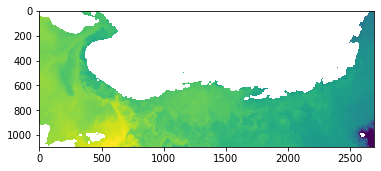

In [6]:
import matplotlib.pyplot as plt
plt.imshow(havbris_combined.temperature[0,0,:,:])

In [8]:
def create_validation_stats_from_infile():
    infile = 'inference_list.csv'
    #df = pd.read_csv(infile, comment='#')
    inference_files_paths, plot_titles, inference_run_id, inferece_epoch, plot_dict = get_inference_file_info(infile)
    norkyst3, havbris_combined = open_datasets_inf(inference_files_paths,
                        truth_norkyst3_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/',
                        truth_file_name_template = "{year}/norkyst800-{year}{month:02d}{day:02d}.nc",
                        variables=plot_dict['variables'],
                        s_rho = -1,
                        crop_border = True,
                        debug=True)
    create_stat_csv_plot_multiple_inf(norkyst3, havbris_combined, plot_dict, plot_titles)
create_validation_stats_from_infile()

Try to read file : /lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_48h_2ae52_e030_s120436.nc

File exists!

File exists and is read!

Variables in the dataset:
['lat', 'lon', 'h', 'salinity', 'sea_mask', 'temperature', 'u_eastward', 'v_northward', 'zeta', 'Pair', 'Qair', 'Tair', 'Uwind', 'Vwind', 'cos_julian_day', 'cos_latitude', 'cos_local_time', 'cos_longitude', 'f', 'insolation', 'rain', 'river_binary_mask', 'sin_julian_day', 'sin_latitude', 'sin_local_time', 'sin_longitude']

Inferred time-steps:
['2024-04-02T00:00:00.000000000' '2024-04-02T03:00:00.000000000'
 '2024-04-02T06:00:00.000000000' '2024-04-02T09:00:00.000000000'
 '2024-04-02T12:00:00.000000000' '2024-04-02T15:00:00.000000000'
 '2024-04-02T18:00:00.000000000' '2024-04-02T21:00:00.000000000'
 '2024-04-03T00:00:00.000000000' '2024-04-03T03:00:00.000000000'
 '2024-04-03T06:00:00.000000000' '2024-04-03T09:00:00.000000000'
 '2024-04-03T12:00:00.000000000' '2024-04-03T15:00:00.000000000'
 '2024-04

In [7]:
def create_distribution_gifs(inference_path):
    havbris, norkyst3 = open_dataset_inf(inference_path,crop_border=True,
                                         variables=plot_dict['variables'],)
    create_distribution_plots(norkyst3, havbris)

inference_path = '/lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_72h_e5281_e025_s098000.nc'#'/lustre/storeB/project/fou/hi/foccus/ingvild/test_infrence/results/2024-04-02_72h_18d28_e011_s049990.nc'
create_distribution_gifs(inference_path)

File exists and is read!

Attempting to load file: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240402.nc
Successfully loaded: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240402.nc

Attempting to load file: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240403.nc
Successfully loaded: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240403.nc

Attempting to load file: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240404.nc
Successfully loaded: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240404.nc

Attempting to load file: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240405.nc
Successfully loaded: /lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast